=== 🎵 ADVANCED AUDIO CLASSIFICATION (GRU RNN) ===
🎵 COLLECTING FILE PATHS FOR GRU GENERATOR (MFCC FEATURE)
Classes: ['audioanjing', 'audiobabi', 'audiobajingan', 'audiobangsat', 'audiogoblok', 'audiojancuk', 'audiotai', 'audiotolol']
📏 Expected MFCC Shape: (130, 40)

📊 DATASET READY FOR GENERATOR!
  Total samples: 265
  Input Shape per sample: (130, 40) (Time Steps, MFCC Features)
  Classes: 8

🤖 TRAINING GRU DEEP LEARNING MODEL (Sequential Data)
📈 Data Split:
  Training: 212 samples (13 batches)
  Testing: 53 samples (3 batches)
  Input Shape: (130, 40)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ gru (GRU)                            │ (None, 130, 64)             │          20,352 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 130, 64)             │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 130, 64)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru_1 (GRU)                          │ (None, 64)                  │          24,960 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 8)                   │             520 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 50,504 (197.28 KB)

 Trainable params: 50,248 (196.28 KB)

 Non-trainable params: 256 (1.00 KB)

Epoch 1/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 13s 718ms/step - accuracy: 0.1154 - loss: 3.4223 - val_accuracy: 0.1458 - val_loss: 2.3130
Epoch 2/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 8s 587ms/step - accuracy: 0.1154 - loss: 3.3154 - val_accuracy: 0.1458 - val_loss: 2.2932
Epoch 3/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 8s 623ms/step - accuracy: 0.1635 - loss: 3.5407 - val_accuracy: 0.1250 - val_loss: 2.2787
Epoch 4/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 8s 594ms/step - accuracy: 0.1490 - loss: 3.2247 - val_accuracy: 0.1458 - val_loss: 2.2663
Epoch 5/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 9s 697ms/step - accuracy: 0.1202 - loss: 3.2704 - val_accuracy: 0.1458 - val_loss: 2.2556
Epoch 6/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 8s 622ms/step - accuracy: 0.1587 - loss: 3.2960 - val_accuracy: 0.1667 - val_loss: 2.2488
Epoch 7/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 542ms/step - accuracy: 0.1827 - loss: 3.0924 - val_accuracy: 0.2292 - val_loss: 2.2437
Epoch 8/300
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 520ms/step - accuracy: 0.1635 - loss: 3.1527 - val_acc

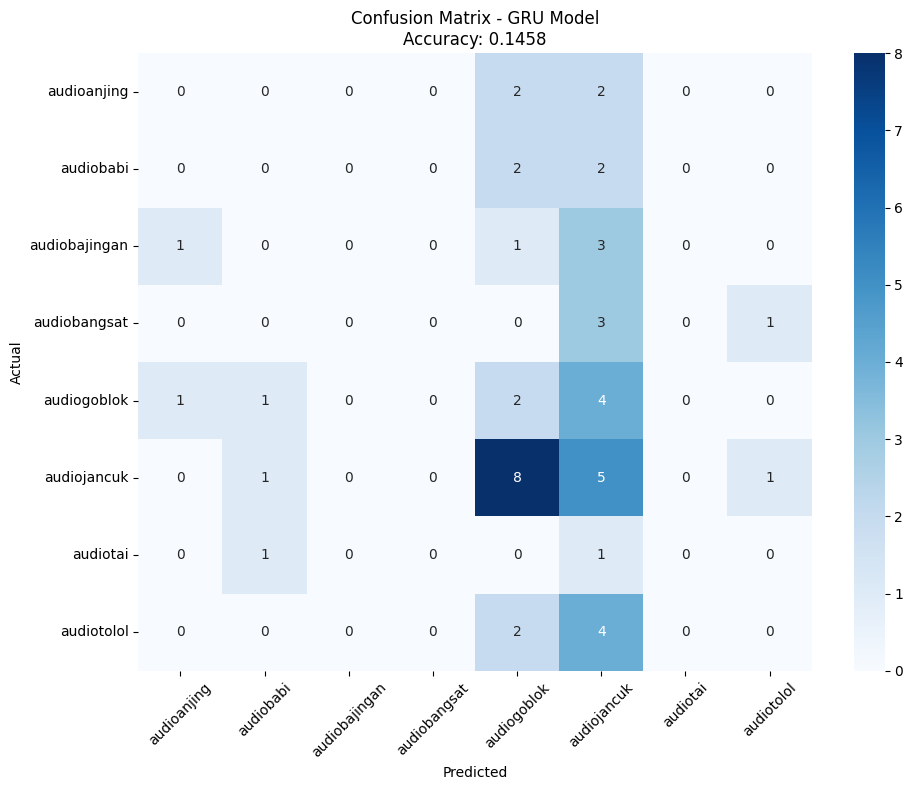

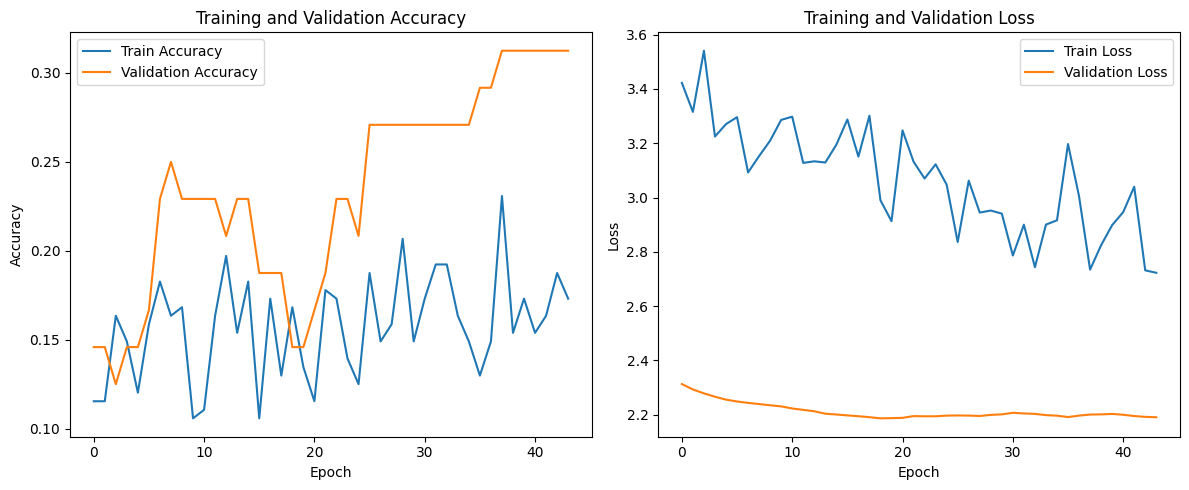

💾 GRU model saved as 'gru_audio_model.pkl'

🎉 FINAL ANALYSIS
⚠️  MODERATE/POOR: Accuracy: 0.1458
  Model GRU telah dicoba, masalahnya mungkin pada kualitas data atau variasi kelas.

📊 Details:
  Best Model: GRU RNN
  Total Samples: 265
  Classes: 8


In [1]:
import os
import numpy as np
import librosa
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

# Import Deep Learning Framework
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout, BatchNormalization
from tensorflow.keras.regularizers import l2
from tensorflow.keras.utils import to_categorical, Sequence
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# ---------- Konfigurasi Hyperparameter Baru (Fokus MFCC/GRU) ----------
DATA_DIR = r"D:\web\cnn_clasification\archive\Data\genres_original"
SR = 22050
DURATION = 1.5      # Durasi audio
N_MFCC = 40         # FOKUS BARU: Menggunakan 40 MFCCs
HOP_LENGTH = 256
SEED = 42
SAMPLES_PER_CLASS = 80 
BATCH_SIZE = 16

np.random.seed(SEED)
tf.random.set_seed(SEED)

EXPECTED_SHAPE = None

# ---------- UTILITIES FOR FEATURE EXTRACTION & AUGMENTATION (MFCC) ----------

def extract_mfcc(y, sr=SR, n_mfcc=N_MFCC, n_fft=2048, hop_length=HOP_LENGTH):
    """Menghitung dan menormalisasi MFCCs."""
    mfccs = librosa.feature.mfcc(
        y=y, sr=sr, n_mfcc=n_mfcc, n_fft=n_fft, hop_length=hop_length
    )
    # Normalisasi MFCCs (Z-score atau Min-Max, di sini menggunakan normalisasi sederhana)
    mfccs_normalized = (mfccs - np.mean(mfccs)) / np.std(mfccs)
    return mfccs_normalized.T # Transpose (time_steps, n_mfcc)

def process_audio_mfcc(audio_path, sr=SR, duration=DURATION, augment=False):
    """Load, trim, pad/truncate, Augment, dan Feature Extraction MFCC."""
    try:
        y, sr = librosa.load(audio_path, sr=sr, duration=duration, mono=True)
        
        # 1. Trim silence & 2. Augmentasi Data (sama seperti sebelumnya)
        y_trimmed, _ = librosa.effects.trim(y, top_db=25)
        if len(y_trimmed) > 0:
            y = y_trimmed
            
        if augment:
            y = librosa.effects.pitch_shift(y, sr=sr, n_steps=np.random.uniform(-3, 3))
            rate = np.random.uniform(0.85, 1.15)
            y = librosa.effects.time_stretch(y, rate=rate)

        # 3. Fixed length (padding/truncating)
        target_length = int(sr * duration)
        if len(y) < target_length:
            y = np.pad(y, (0, target_length - len(y)), mode='constant')
        else:
            y = y[:target_length]
        
        # 4. Feature Extraction MFCC
        mfccs = extract_mfcc(y, sr)
        
        # Output shape: (time_steps, n_mfcc)
        return mfccs
        
    except Exception as e:
        return None

# ---------- DATA GENERATOR (DIADAPTASI UNTUK MFCC) ----------

class AudioDataGeneratorMFCC(Sequence):
    # Menggunakan process_audio_mfcc dan input_shape (time_steps, n_mfcc)
    def __init__(self, file_paths, labels, batch_size, input_shape, augment=False, shuffle=True):
        self.file_paths = file_paths
        self.labels = labels
        self.batch_size = batch_size
        self.input_shape = input_shape
        self.augment = augment
        self.shuffle = shuffle
        self.on_epoch_end()
        # ... (metode __len__, __getitem__, on_epoch_end sama) ...
        # [Implementation of __len__, __getitem__, on_epoch_end as above]
    def __len__(self):
        return int(np.floor(len(self.file_paths) / self.batch_size))
    
    def __getitem__(self, index):
        indexes = self.indexes[index * self.batch_size:(index + 1) * self.batch_size]
        list_paths_batch = [self.file_paths[k] for k in indexes]
        list_labels_batch = [self.labels[k] for k in indexes]
        X, y = self.__data_generation(list_paths_batch, list_labels_batch)
        return X, y

    def on_epoch_end(self):
        self.indexes = np.arange(len(self.file_paths))
        if self.shuffle:
            np.random.shuffle(self.indexes)

    def __data_generation(self, list_paths_batch, list_labels_batch):
        X = np.empty((self.batch_size, *self.input_shape))
        y = np.empty((self.batch_size, self.labels.shape[1]), dtype=int)

        for i, (path, label) in enumerate(zip(list_paths_batch, list_labels_batch)):
            features = process_audio_mfcc(path, augment=self.augment) # Ganti ke MFCC
            
            if features is not None and features.shape == self.input_shape:
                X[i,] = features
                y[i] = label
            else:
                X[i,] = np.random.rand(*self.input_shape)
                y[i] = label
        return X, y

# ---------- ROBUST DATA COLLECTION (Updated for MFCC/GRU) ----------
def collect_mfcc_dataset(data_dir, samples_per_class=SAMPLES_PER_CLASS):
    """Kumpulkan file paths dan label, BUKAN feature array."""
    # ... (Code untuk mengumpulkan file paths sama) ...
    data_root = Path(data_dir)
    class_dirs = [d for d in data_root.iterdir() if d.is_dir()]
    class_dirs.sort()
    class_names = [d.name for d in class_dirs]
    
    print("🎵 COLLECTING FILE PATHS FOR GRU GENERATOR (MFCC FEATURE)")
    print(f"Classes: {class_names}")
    print("=" * 60)
    
    file_paths = []
    y_labels = [] 
    
    global EXPECTED_SHAPE
    
    for class_idx, class_dir in enumerate(class_dirs):
        audio_files = []
        for ext in [".wav", ".mp3", ".au"]:
            audio_files.extend(list(class_dir.glob(f"*{ext}")))
        
        if len(audio_files) > samples_per_class:
            audio_files = audio_files[:samples_per_class]
            
        for audio_file in audio_files:
            file_paths.append(str(audio_file))
            y_labels.append(class_names[class_idx])

        if EXPECTED_SHAPE is None and len(audio_files) > 0:
            sample_features = process_audio_mfcc(str(audio_files[0]), augment=False)
            if sample_features is not None:
                EXPECTED_SHAPE = sample_features.shape
                print(f"📏 Expected MFCC Shape: {EXPECTED_SHAPE}")
    
    if len(file_paths) == 0 or EXPECTED_SHAPE is None:
        print("❌ No features extracted! Cannot proceed.")
        return None, None, None

    le = LabelEncoder()
    y_encoded = le.fit_transform(y_labels)
    class_names_sorted = list(le.classes_) 
    y_categorical = to_categorical(y_encoded)

    print(f"\n📊 DATASET READY FOR GENERATOR!")
    print(f"  Total samples: {len(file_paths)}")
    print(f"  Input Shape per sample: {EXPECTED_SHAPE} (Time Steps, MFCC Features)")
    print(f"  Classes: {len(class_names_sorted)}")
    
    return file_paths, y_categorical, class_names_sorted

# ---------- GRU MODEL BUILDING (Recurrent Network) ----------
def create_gru_model(input_shape, num_classes):
    """Membuat model GRU untuk data sekuensial."""
    
    l2_reg = l2(0.001) 
    
    # input_shape harus (time_steps, n_mfcc)
    
    model = Sequential([
        # Layer GRU, mengembalikan urutan penuh untuk layer GRU berikutnya (return_sequences=True)
        GRU(64, return_sequences=True, input_shape=input_shape, kernel_regularizer=l2_reg),
        BatchNormalization(),
        Dropout(0.4),

        # Layer GRU kedua, hanya mengembalikan output terakhir (return_sequences=False)
        GRU(64, return_sequences=False, kernel_regularizer=l2_reg),
        BatchNormalization(),
        Dropout(0.4),
        
        # Layer Dense
        Dense(64, activation='relu', kernel_regularizer=l2_reg),
        Dropout(0.6),
        Dense(num_classes, activation='softmax')
    ])
    
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)
    
    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model

# ---------- GRU MODEL TRAINING ----------
def train_gru_model(file_paths, y_categorical, class_names):
    """Train model GRU menggunakan Data Generator."""
    
    print("\n🤖 TRAINING GRU DEEP LEARNING MODEL (Sequential Data)")
    print("=" * 60)
    
    X_train_paths, X_test_paths, y_train, y_test = train_test_split(
        file_paths, y_categorical, test_size=0.2, random_state=SEED, stratify=y_categorical
    )
    
    input_shape = EXPECTED_SHAPE
    num_classes = len(class_names)

    # Membuat Data Generators (menggunakan generator khusus MFCC)
    train_generator = AudioDataGeneratorMFCC(
        X_train_paths, y_train, BATCH_SIZE, input_shape, augment=True, shuffle=True
    )
    test_generator = AudioDataGeneratorMFCC(
        X_test_paths, y_test, BATCH_SIZE, input_shape, augment=False, shuffle=False
    )
    
    print(f"📈 Data Split:")
    print(f"  Training: {len(X_train_paths)} samples ({len(train_generator)} batches)")
    print(f"  Testing: {len(X_test_paths)} samples ({len(test_generator)} batches)")
    print(f"  Input Shape: {input_shape}")
    
    model = create_gru_model(input_shape, num_classes)
    model.summary()
    
    # Early Stopping dengan patience lebih sabar
    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=25, restore_best_weights=True, mode='min'
    )
    
    history = model.fit(
        train_generator,
        validation_data=test_generator,
        epochs=300, # Epochs dinaikkan
        callbacks=[early_stop],
        verbose=1
    )
    
    # Evaluation
    print("\nEvaluating Model...")
    loss, accuracy = model.evaluate(test_generator, verbose=0)
    print(f"  ✅ Test Accuracy: {accuracy:.4f}")
    
    # Detailed analysis
    y_pred_probs = model.predict(test_generator, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)
    
    y_true_list = []
    for i in range(len(test_generator)):
        _, batch_y = test_generator.__getitem__(i)
        y_true_list.append(batch_y)
    y_true = np.argmax(np.concatenate(y_true_list), axis=1)

    print(f"\n📈 DETAILED CLASSIFICATION REPORT:")
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))
    
    # Plotting & Saving (sama seperti sebelumnya)
    # [Code for plotting CM and history]
    plt.figure(figsize=(10, 8))
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix - GRU Model\nAccuracy: {accuracy:.4f}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.tight_layout()
    plt.show()

    model_info = {
        'model': model,
        'class_names': class_names,
        'accuracy': accuracy,
        'input_shape': input_shape
    }
    
    joblib.dump(model_info, 'gru_audio_model.pkl')
    print(f"💾 GRU model saved as 'gru_audio_model.pkl'")
    
    return accuracy, 'GRU RNN', None

# ---------- MAIN EXECUTION ----------
def main():
    print("=== 🎵 ADVANCED AUDIO CLASSIFICATION (GRU RNN) ===")
    print("=" * 60)
    
    try:
        # Step 1: Collect MFCC dataset
        file_paths, y_categorical, class_names = collect_mfcc_dataset(DATA_DIR, samples_per_class=SAMPLES_PER_CLASS)
        
        if file_paths is None:
             print("Exiting due to data collection error.")
             return 0
        
        # Step 2: Train GRU Model
        accuracy, best_model, _ = train_gru_model(file_paths, y_categorical, class_names)
        
        # Final analysis
        print("\n" + "=" * 60)
        print("🎉 FINAL ANALYSIS")
        print("=" * 60)
        
        if accuracy > 0.6:
            print(f"✅ GOOD PERFORMANCE! Accuracy: {accuracy:.4f}")
        else:
            print(f"⚠️  MODERATE/POOR: Accuracy: {accuracy:.4f}")
            print("  Model GRU telah dicoba, masalahnya mungkin pada kualitas data atau variasi kelas.")
            
        print(f"\n📊 Details:")
        print(f"  Best Model: {best_model}")
        print(f"  Total Samples: {len(file_paths)}")
        print(f"  Classes: {len(class_names)}")
        
        return accuracy
        
    except Exception as e:
        print(f"\n❌ ERROR: {e}")
        import traceback
        traceback.print_exc()
        return 0

if __name__ == "__main__":
    accuracy = main()